In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

# Read dataset

In [2]:
import pandas as pd

df = pd.read_csv(
    "SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "message"],
    encoding="utf-8"
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df.shape

(5572, 2)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 542.9 KB


In [5]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(403)

In [7]:
df.drop_duplicates().reset_index(drop=True)

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5164,spam,This is the 2nd time we have tried 2 contact u...
5165,ham,Will ü b going to esplanade fr home?
5166,ham,"Pity, * was in mood for that. So...any other s..."
5167,ham,The guy did some bitching but I acted like i'd...


In [8]:
df.shape

(5572, 2)

# EDA

In [9]:
df['label'].unique()

<ArrowStringArray>
['ham', 'spam']
Length: 2, dtype: str

In [10]:
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

# visualize the distribution

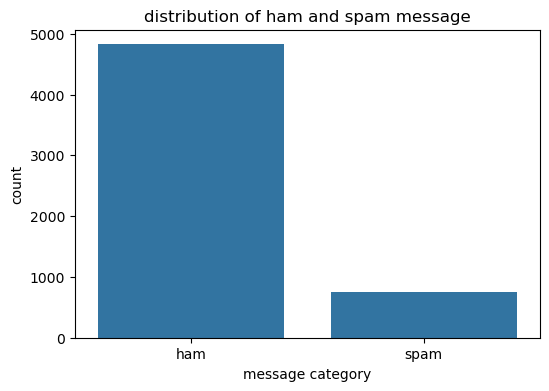

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='label')
plt.title('distribution of ham and spam message')
plt.xlabel('message category')
plt.ylabel('count')
plt.show()

# claculate percentage of each class

In [12]:
df['label'].value_counts(normalize=True)*100

label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64

# analyze message length

In [13]:
df['message_length']=df['message'].apply(len)

In [21]:
df['message_length']

0       111
1        29
2       155
3        49
4        61
       ... 
5567    160
5568     36
5569     57
5570    125
5571     26
Name: message_length, Length: 5572, dtype: int64

In [14]:
df.head()

,label,message,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


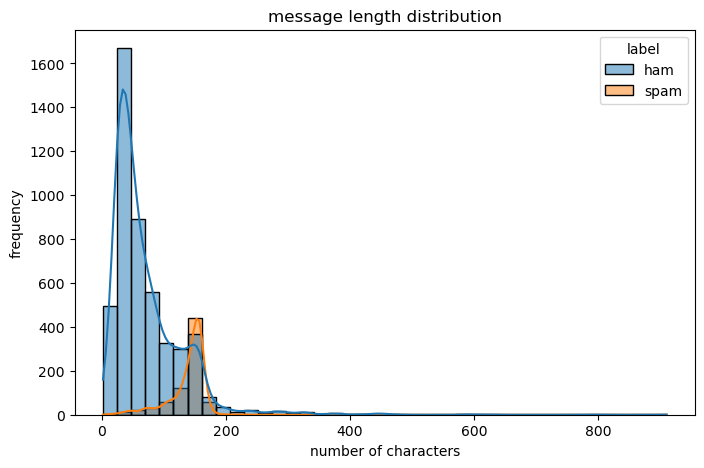

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(data=df,x='message_length',hue='label',bins=40,kde=True)
plt.title('message length distribution')
plt.xlabel('number of characters')
plt.ylabel('frequency')
plt.show()

# Text Cleaning

In [22]:
# text cleaning means removing unnecessary elements from text so that the model cal learn useful patterns

In [16]:
def clean_text(text):

    #converte text into lowercase
    text=text.lower()

    #remove URLs
    text=re.sub(r"http\S+|www\S+","",text)

    #remove email address
    text=re.sub(r"\S+@\S+","",text)

    #remove punctuation
    text=text.translate(str.maketrans("","",string.punctuation))

    #remove extra spaces
    text=re.sub(r"\s+"," ",text).strip()

    return text

In [19]:
sample="WINNER!! Congratilations,claim your FREE prize!!!"

print("Original Text:")
print(sample)

print("\nCleaned Text:")
print(clean_text(sample))

Original Text:
WINNER!! Congratilations,claim your FREE prize!!!

Cleaned Text:
winner congratilationsclaim your free prize


# Apply cleaning to the dataset

In [20]:
df['cleaned_message']=df['message'].apply(clean_text)
df[['message','cleaned_message']].head()   

,message,cleaned_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


# convert labels into numbers

In [23]:
df['label_num']=df['label'].map({
    'ham':0,
    'spam':1
})

df[['label','label_num']].head()

,label,label_num
0,ham,0
1,ham,0
2,spam,1
3,ham,0
4,ham,0


In [24]:
X=df['cleaned_message']
y=df['label_num']

In [25]:
X.shape

(5572,)

In [26]:
y.shape

(5572,)

In [27]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [28]:
X_train.shape

(4457,)

In [29]:
X_test.shape

(1115,)

In [30]:
y_train.shape

(4457,)

In [31]:
y_test.shape

(1115,)

# Convert Text into Numbers using TF-TDF

In [ ]:
What is TF-IDF?

TF-IDF stands for:

Term Frequency – Inverse Document Frequency

It calculates the importance of a word in a document compared to the complete collection of documents.

In [33]:
tfidf=TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words='english'
)

In [34]:
tfidf

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.

# Explanation of parameters

In [ ]:
Parameter

Parameter:                              Meaning:

max_features=5000                       Use at most 5,000 features

ngram_range=(1,2)                       Use single words and two-word combinations

stop_words="english"                    Remove common English stop words


 # 2 fit TF_IDF on training data

In [35]:
X_train_tfidf=tfidf.fit_transform(X_train)
X_test_tfidf=tfidf.transform(X_test)

In [37]:
X_train_tfidf.shape

(4457, 5000)

In [38]:
X_test_tfidf.shape

(1115, 5000)

In [39]:
print(X_train_tfidf[0])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2 stored elements and shape (1, 5000)>
  Coords	Values
  (0, 1683)	0.6634978999490201
  (0, 1000)	0.7481781450719073


In [40]:
from sklearn.dummy import DummyClassifier

In [41]:
baseline=DummyClassifier(strategy="most_frequent")
baseline.fit(X_train,y_train)
baseline_prediction=baseline.predict(X_test_tfidf)

In [42]:
baseline

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


In [43]:
acc=accuracy_score(y_test,baseline_prediction)

In [44]:
acc

0.8663677130044843

In [46]:
cr=classification_report(y_test,baseline_prediction)

C:\Users\Arati\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Arati\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Arati\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [47]:
print(cr)

              precision    recall  f1-score   support

           0       0.87      1.00      0.93       966
           1       0.00      0.00      0.00       149

    accuracy                           0.87      1115
   macro avg       0.43      0.50      0.46      1115
weighted avg       0.75      0.87      0.80      1115



In [48]:
cm=confusion_matrix(y_test,baseline_prediction)

In [49]:
print(cm)

[[966   0]
 [149   0]]


In [51]:
from sklearn.naive_bayes import MultinomialNB

In [52]:
nb_model=MultinomialNB()

In [53]:
nb_model.fit(X_train_tfidf,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [54]:
nb_predictions=nb_model.predict(X_test_tfidf)

In [56]:
print(nb_predictions[:10])

[0 0 0 1 0 0 0 0 0 0]


In [57]:
nb_accuracy=accuracy_score(y_test,nb_predictions)

In [58]:
nb_accuracy

0.967713004484305

In [59]:
n_cr=classification_report(y_test,nb_predictions)

In [61]:
print(n_cr)

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       1.00      0.76      0.86       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



In [63]:
n_cm=confusion_matrix(y_test,nb_predictions)

In [64]:
print(n_cm)

[[966   0]
 [ 36 113]]


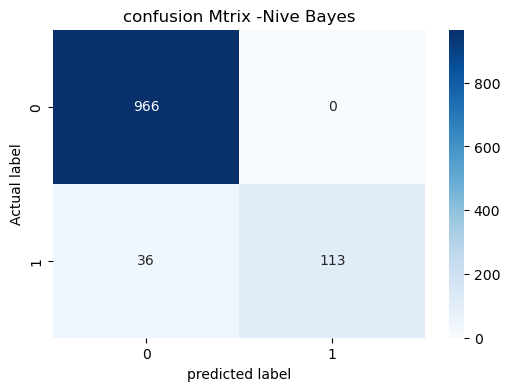

In [66]:
plt.figure(figsize=(6,4))
sns.heatmap(n_cm,annot=True,fmt='d',cmap='Blues')

plt.title("confusion Mtrix -Nive Bayes")
plt.xlabel("predicted label")
plt.ylabel("Actual label")
plt.show()

In [67]:
lr_model=LogisticRegression(max_iter=1000,class_weight='balanced')

In [68]:
lr_model.fit(X_train_tfidf,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [70]:
lr_prediction=lr_model.predict(X_test_tfidf)

In [71]:
lr_prediction

array([0, 0, 0, ..., 0, 0, 0], shape=(1115,))

In [73]:
lr_acc=accuracy_score(y_test,lr_prediction)

In [74]:
lr_acc

0.9748878923766816

In [75]:
lr_cr=classification_report(y_test,lr_prediction)

In [77]:
print(lr_cr)

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       966
           1       0.90      0.91      0.91       149

    accuracy                           0.97      1115
   macro avg       0.94      0.95      0.95      1115
weighted avg       0.98      0.97      0.97      1115



In [78]:
lr_cm=confusion_matrix(y_test,lr_prediction)

In [79]:
print(lr_cm)

[[951  15]
 [ 13 136]]


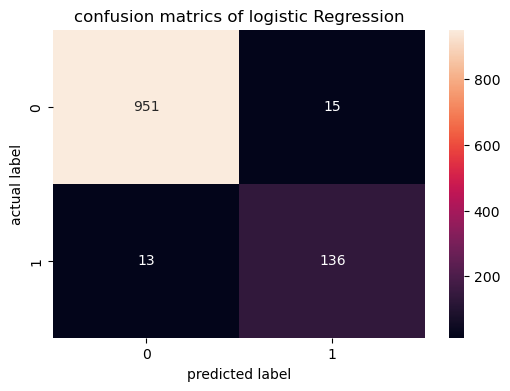

In [80]:
plt.figure(figsize=(6,4))
sns.heatmap(lr_cm,annot=True,fmt='d')
plt.title('confusion matrics of logistic Regression')
plt.xlabel('predicted label')
plt.ylabel('actual label')
plt.show()

In [83]:
result=pd.DataFrame({
    'model':['Baseline','multinomial naive bayes','logistic regression'],
    'Accuracy':[
        accuracy_score(y_test,baseline_prediction),
        accuracy_score(y_test,nb_predictions),
        accuracy_score(y_test,lr_prediction)
    ]
})
result
    
    
    
                
                

,model,Accuracy
0,Baseline,0.866368
1,multinomial naive bayes,0.967713
2,logistic regression,0.974888


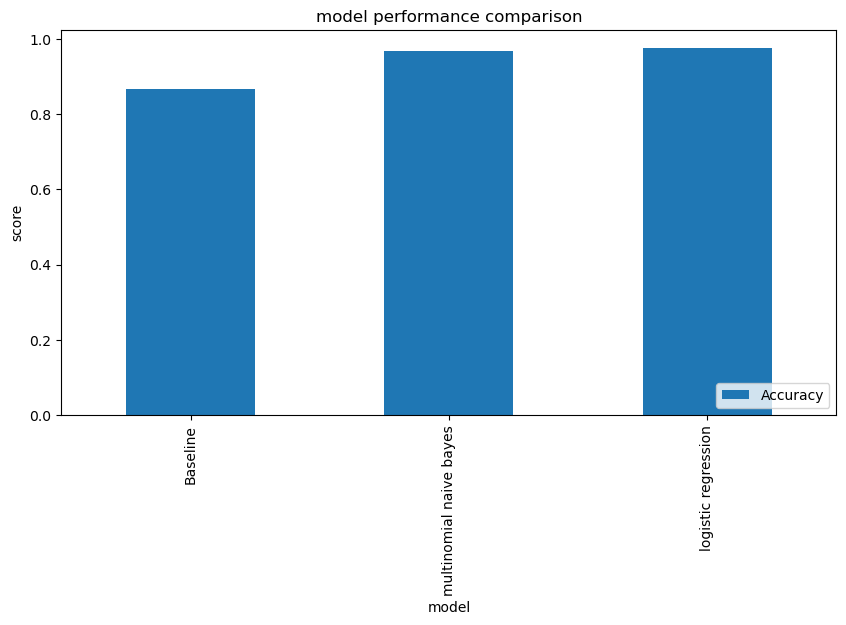

In [85]:
result.set_index('model')[['Accuracy']].plot(kind='bar',figsize=(10,5))
plt.title('model performance comparison')
plt.ylabel('score')
plt.legend(loc='lower right')
plt.show()

In [86]:
def predict_message(message):

    # Step 1: Clean message
    cleaned = clean_text(message)

    # Step 2: Convert text into TF-IDF vector
    vectorized = tfidf.transform([cleaned])

    # Step 3: Predict using Naive Bayes
    prediction = nb_model.predict(vectorized)[0]

    # Step 4: Get prediction probability
    probabilities = nb_model.predict_proba(vectorized)[0]

    # Step 5: Convert numerical output into label
    if prediction == 1:
        result = "Spam"
    else:
        result = "Ham"

    # Step 6: Display result
    print("Original Message:", message)

    print("Cleaned Message:", cleaned)

    print("Prediction:", result)

    print("Ham Probability:", round(probabilities[0] * 100, 2), "%")

    print("Spam Probability:", round(probabilities[1] * 100, 2), "%")

    return result

In [87]:
predict_message("Hey, how are you?")

predict_message("Are you coming to college tomorrow?")

predict_message("Please call me when you reach home.")

predict_message("I will meet you at 5 PM.")

Original Message: Hey, how are you?
Cleaned Message: hey how are you
Prediction: Ham
Ham Probability: 98.66 %
Spam Probability: 1.34 %
Original Message: Are you coming to college tomorrow?
Cleaned Message: are you coming to college tomorrow
Prediction: Ham
Ham Probability: 99.21 %
Spam Probability: 0.79 %
Original Message: Please call me when you reach home.
Cleaned Message: please call me when you reach home
Prediction: Ham
Ham Probability: 97.71 %
Spam Probability: 2.29 %
Original Message: I will meet you at 5 PM.
Cleaned Message: i will meet you at 5 pm
Prediction: Ham
Ham Probability: 95.83 %
Spam Probability: 4.17 %


'Ham'

In [88]:
predict_message("Congratulations! You won a free prize.")

predict_message("Claim your free cash reward now!")

predict_message("You have won a lottery. Call now to claim.")

predict_message("Get a special offer today. Limited time only.")

Original Message: Congratulations! You won a free prize.
Cleaned Message: congratulations you won a free prize
Prediction: Spam
Ham Probability: 6.99 %
Spam Probability: 93.01 %
Original Message: Claim your free cash reward now!
Cleaned Message: claim your free cash reward now
Prediction: Spam
Ham Probability: 11.92 %
Spam Probability: 88.08 %
Original Message: You have won a lottery. Call now to claim.
Cleaned Message: you have won a lottery call now to claim
Prediction: Spam
Ham Probability: 6.16 %
Spam Probability: 93.84 %
Original Message: Get a special offer today. Limited time only.
Cleaned Message: get a special offer today limited time only
Prediction: Ham
Ham Probability: 94.61 %
Spam Probability: 5.39 %


'Ham'

In [89]:
import joblib
import os

In [91]:
os.makedirs('models',exist_ok=True)

In [93]:
joblib.dump(nb_model,'models/spam_model.pkl')
joblib.dump(tfidf,'models/tfidf_vectorizer.pkl')

['models/tfidf_vectorizer.pkl']

In [94]:
loaded_model=joblib.load('models/spam_model.pkl')
loaded_tfidf=joblib.load('models/tfidf_vectorizer.pkl')

In [96]:
new_message = "Congratulations! You won a free gift."

cleaned = clean_text(new_message)

vector = loaded_tfidf.transform([cleaned])

prediction = loaded_model.predict(vector)[0]

if prediction == 1:
    print("Spam Message")
else:
    print("Ham Message")

Spam Message
